## 1) Problem Identification

## 2) Business Analysis

## 3) Objectives

## 4) Dataset Information

## 5) Technologies Used

## 6) Project Workflow

### 1) Import Libraries

In [2]:
# Basics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 2) Data Collection

In [8]:
flight_cost = pd.read_excel('C:/Users/Admin/Documents/GitHub/flight-ticket-price-prediction-linear-regression/Dataset/Flight_Fare.xlsx')
flight_cost

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


### 3) Data Understanding

In [9]:
flight_cost.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [10]:
flight_cost.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [11]:
flight_cost.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

### 4) Exploratory Data Analysis (EDA)

#### 1) Dataset Shape

In [12]:
flight_cost.shape

(10683, 11)

#### 2) Data Type

In [14]:
flight_cost.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

#### 3) Missing Values

In [15]:
flight_cost.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

##### Observation

#### 4) Duplicates

In [17]:
flight_cost.duplicated().sum()

np.int64(220)

##### Observation

In [ ]:
In Flight Fare Dataset have 220 duplicate values, so we need remove this unwanted datas.

#### 5) Statistical Summary

In [18]:
flight_cost.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


#### 6) Correlation Analysis

In [19]:
corr_analysis = flight_cost.corr(numeric_only=True)
corr_analysis

,Price
Price,1.0


#### 7) Class Distibution

In [20]:
flight_cost.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [21]:
flight_cost['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [23]:
flight_cost['Source'].value_counts()

Source
Delhi       4537
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [24]:
flight_cost['Destination'].value_counts()

Destination
Cochin       4537
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [28]:
flight_cost['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [29]:
flight_cost['Additional_Info'].value_counts()

Additional_Info
No info                         8345
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

#### 8) Outliers Detection

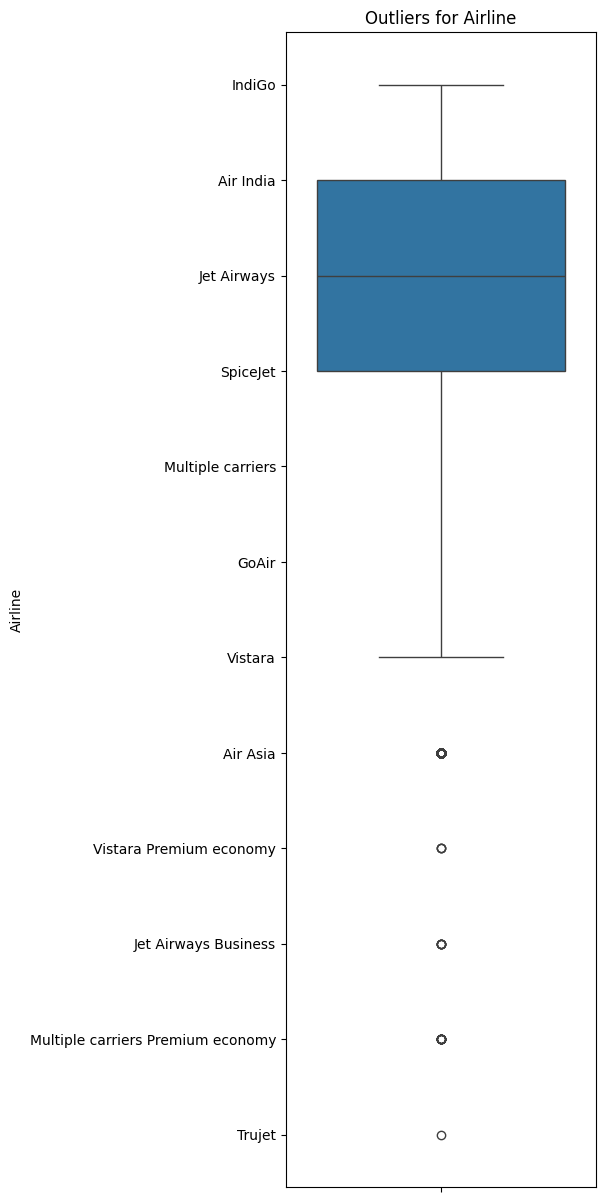

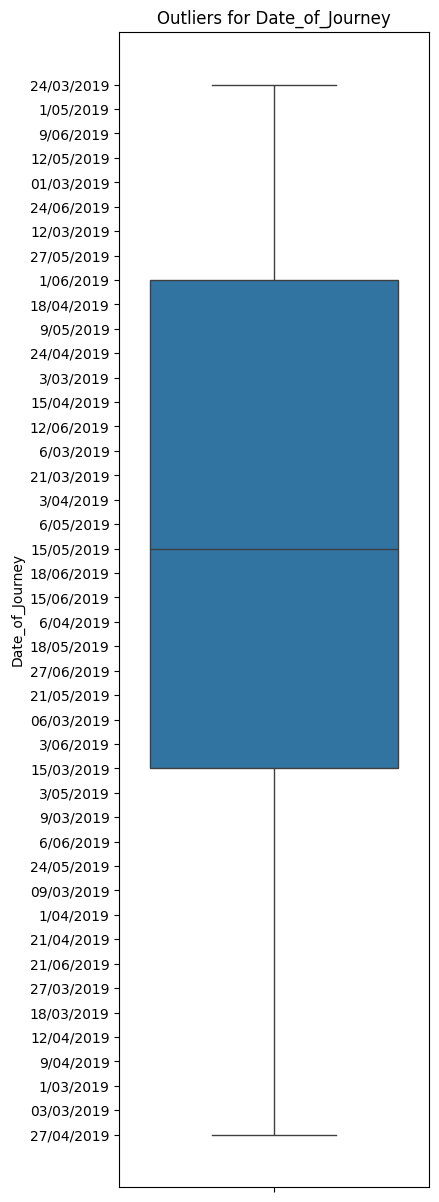

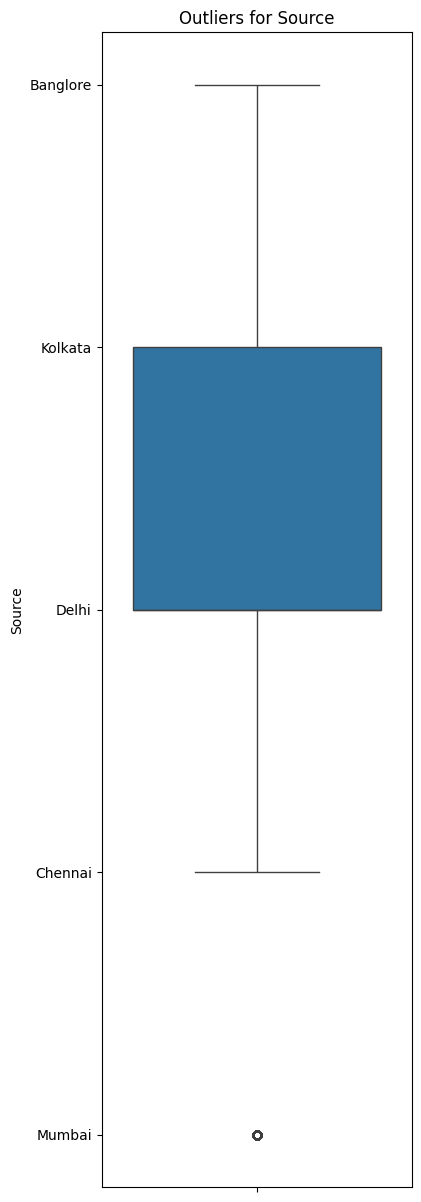

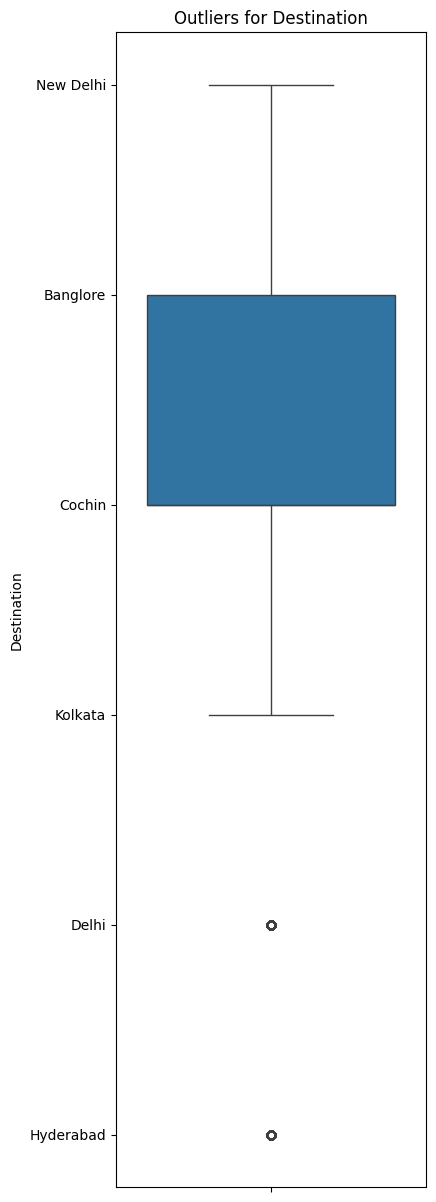

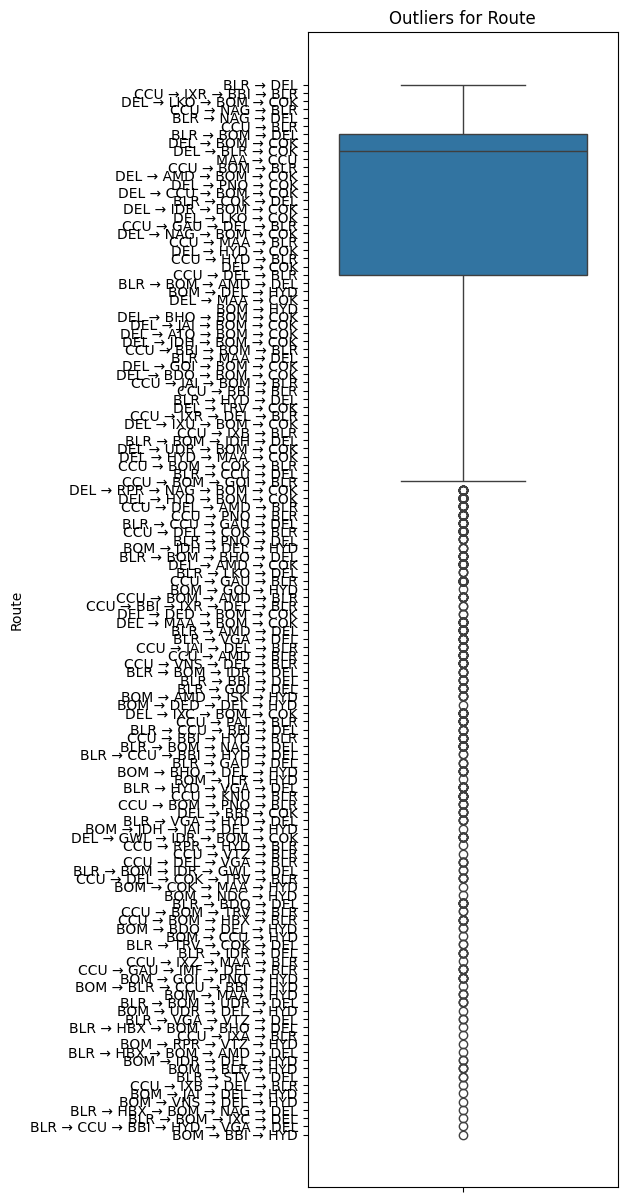

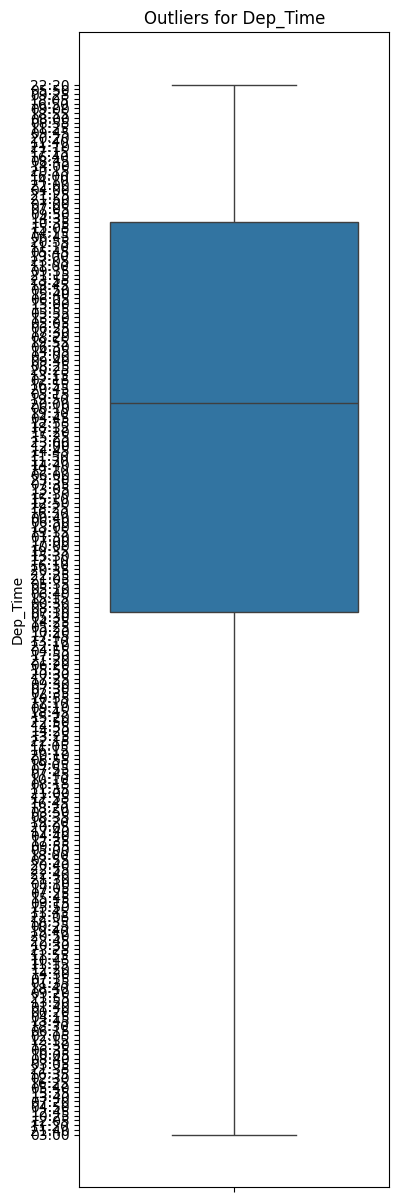

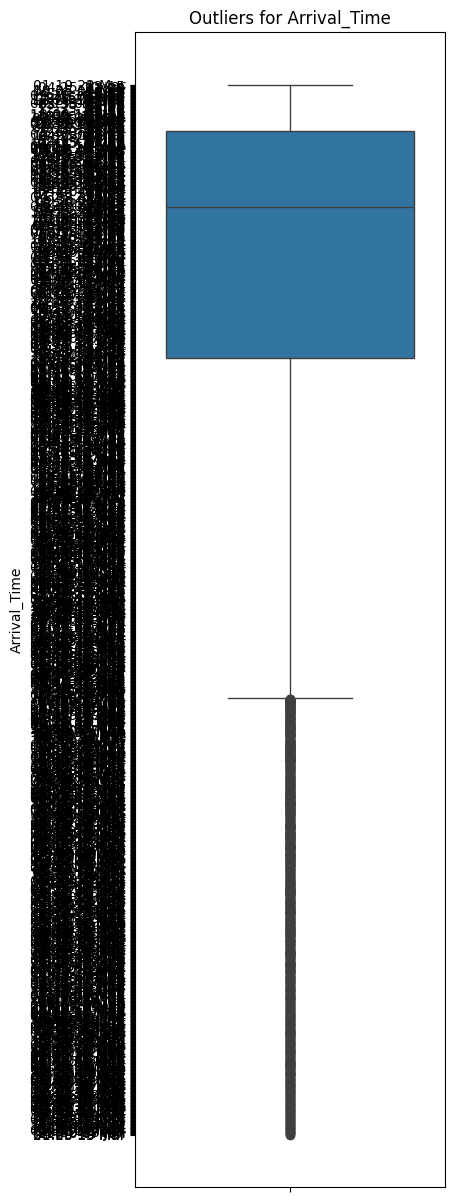

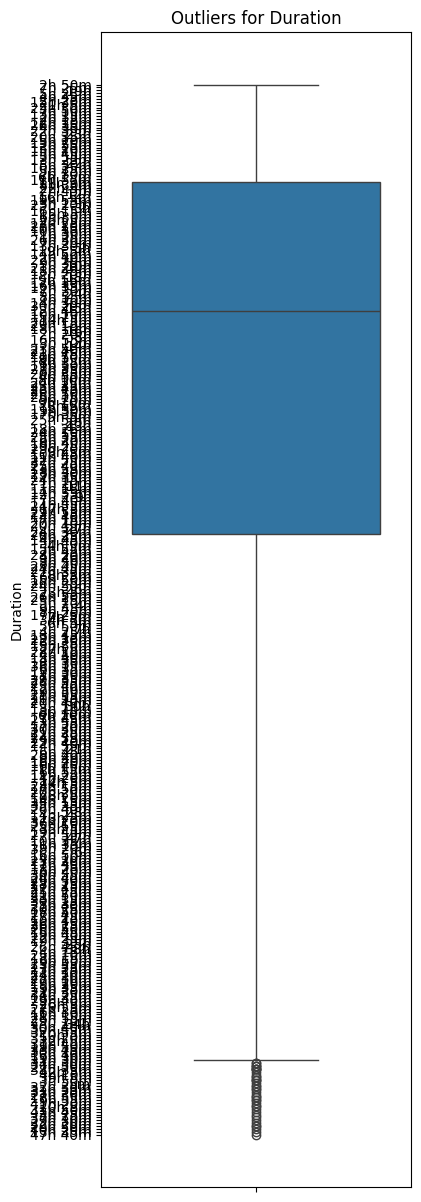

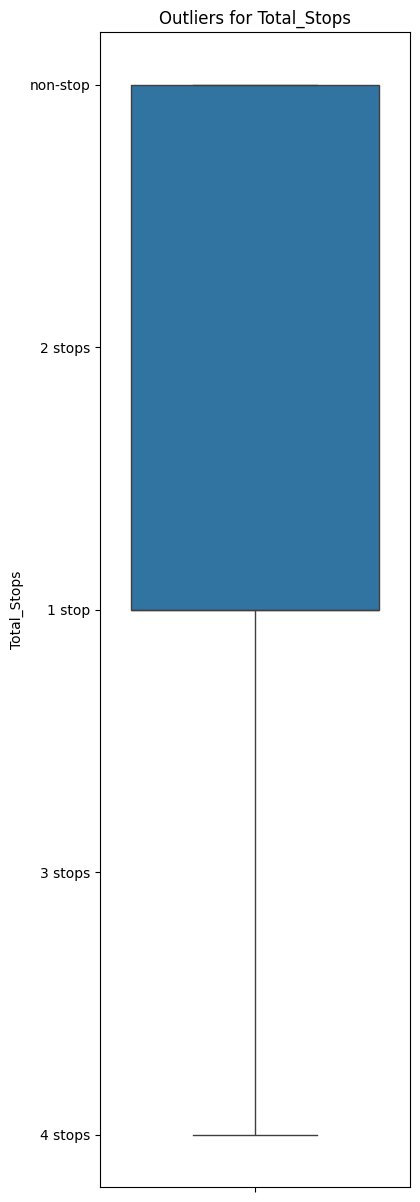

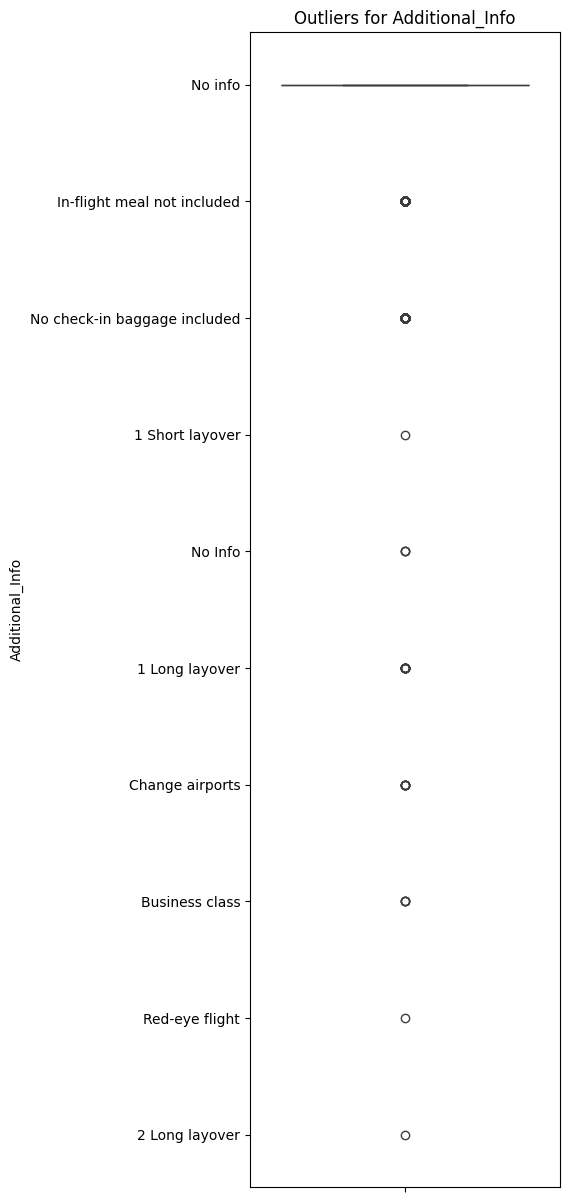

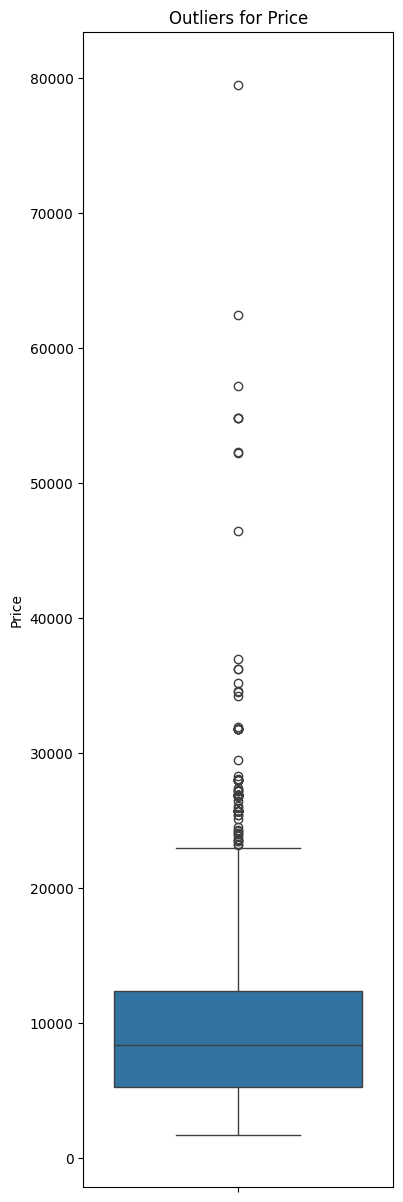

In [34]:
columns = flight_cost.columns

for out_columns in columns:
    plt.figure(figsize=(4,15))

    sns.boxplot(y=flight_cost[out_columns])

    plt.title(f'Outliers for {out_columns}')

    plt.show()

##### Observation

#### 9) Feature Distribution

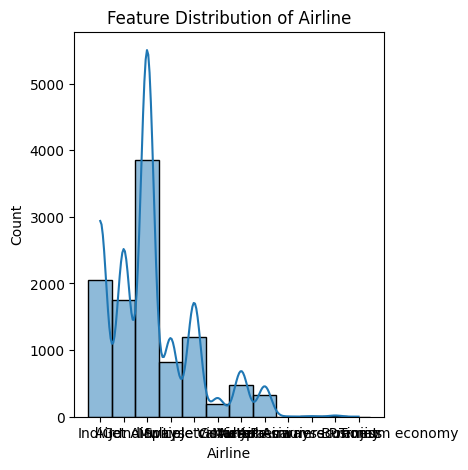

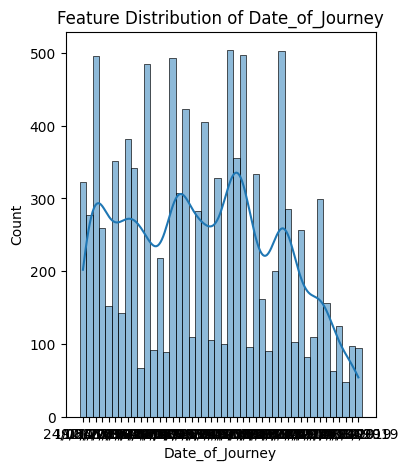

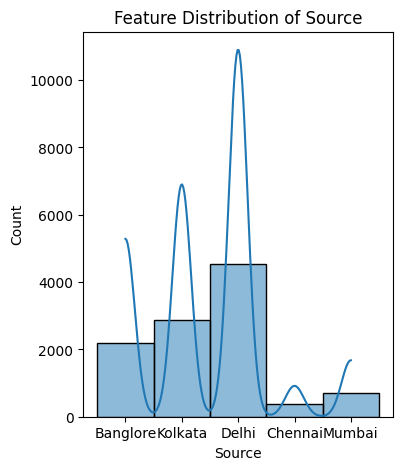

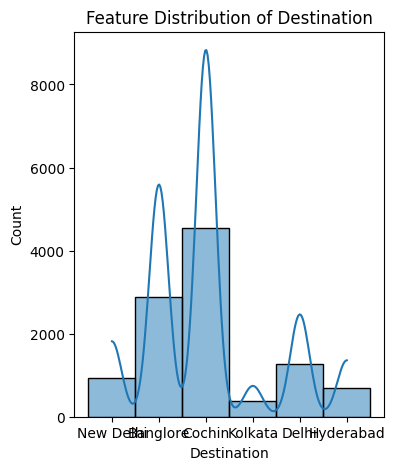

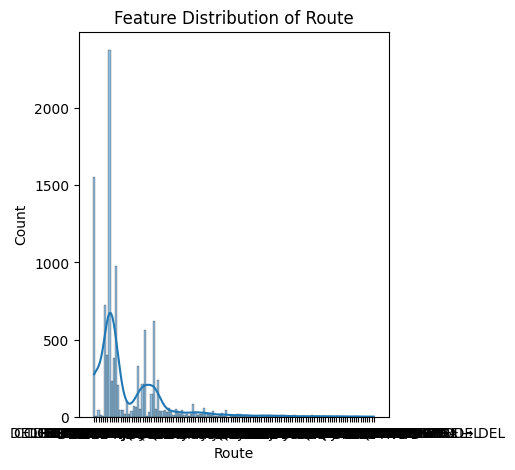

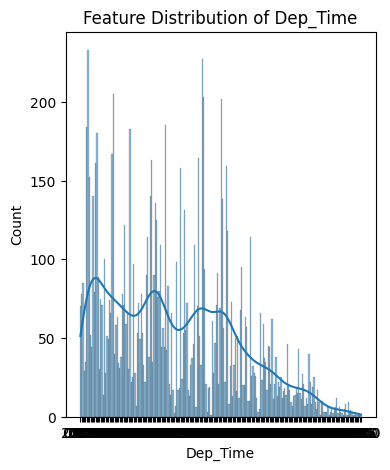

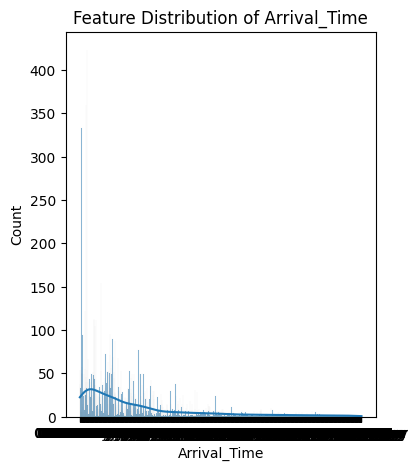

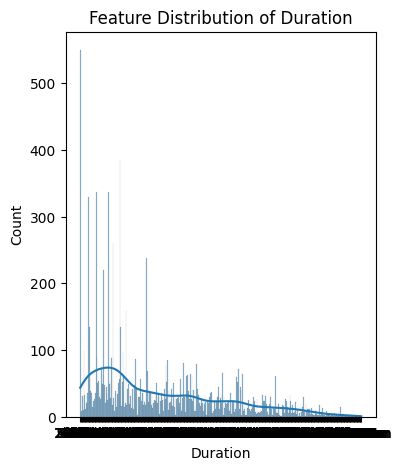

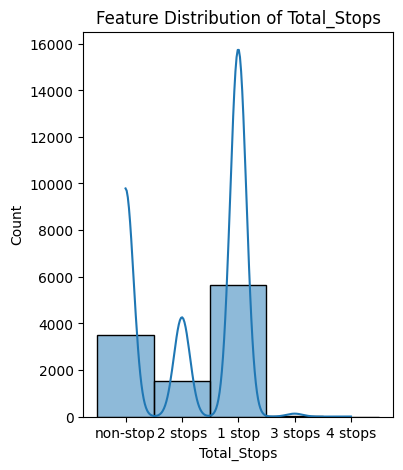

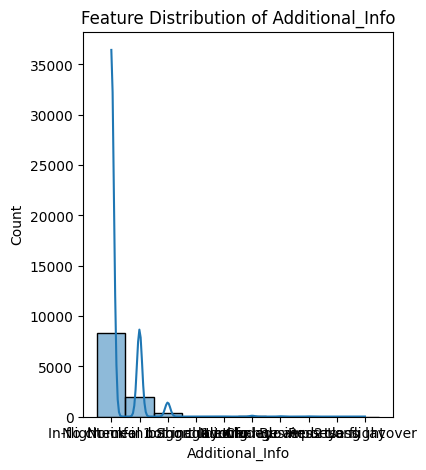

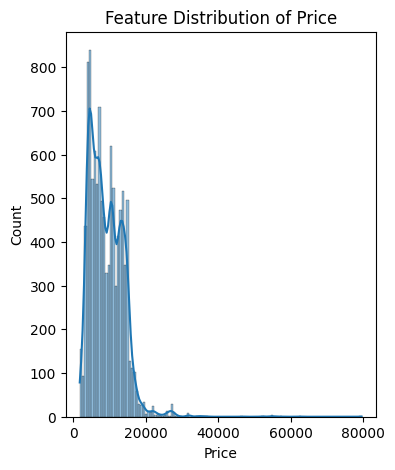

In [36]:
column = flight_cost.columns

for fea_cols in column:
    plt.figure(figsize=(4,5))

    sns.histplot(data=flight_cost[fea_cols], kde=True)
    plt.title(f'Feature Distribution of {fea_cols}')

    plt.show()

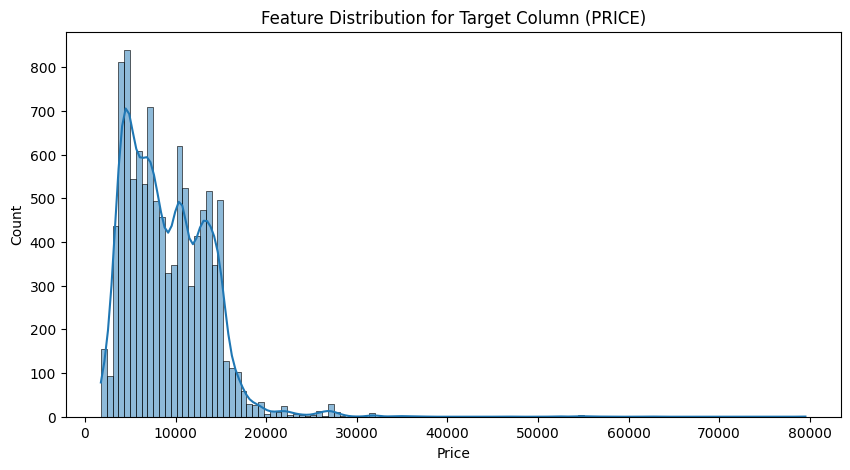

In [40]:
# Target Column
plt.figure(figsize=(10,5))

sns.histplot(x=flight_cost['Price'], kde=True)
plt.title('Feature Distribution for Target Column (PRICE)')

plt.show()

#### Bi-Variant Analysis

In [41]:
flight_cost.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


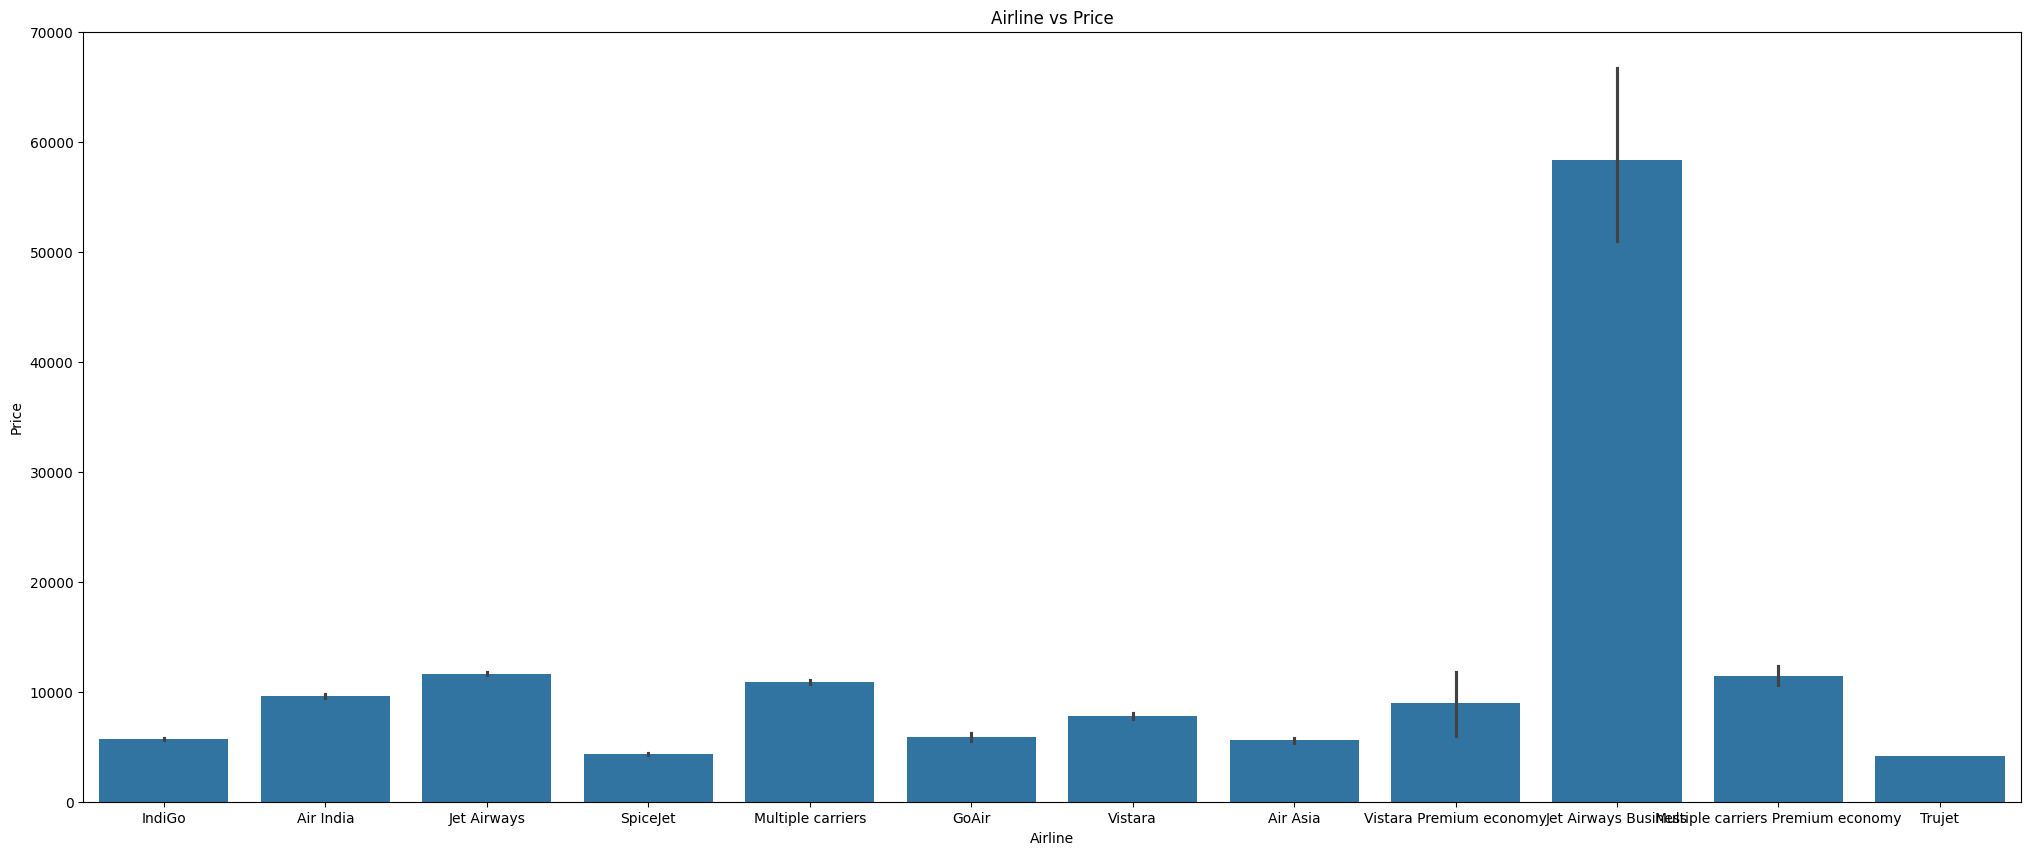

In [55]:
# Airline vs Price (C vs N)

plt.figure(figsize=(25,10))

sns.barplot(x='Airline',
            y='Price',
            data=flight_cost
           )
plt.title('Airline vs Price')

plt.show()

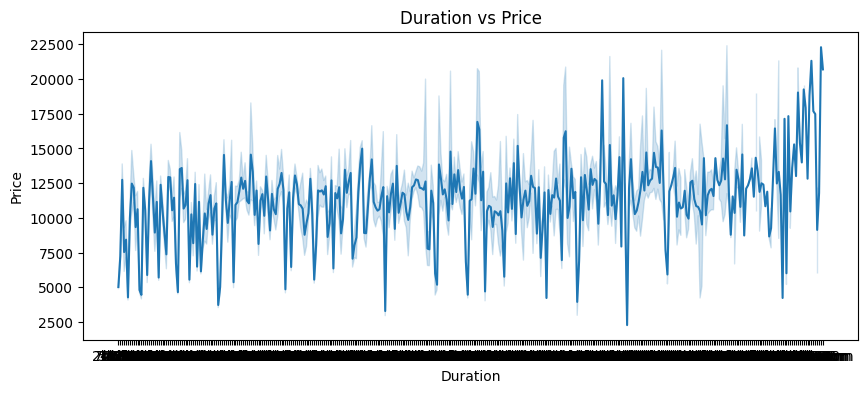

In [58]:
# Duration vs Price (C vs N)

plt.figure(figsize=(10,4))

sns.lineplot(x='Duration',
            y='Price',
            data=flight_cost
           )
plt.title('Duration vs Price')

plt.show()

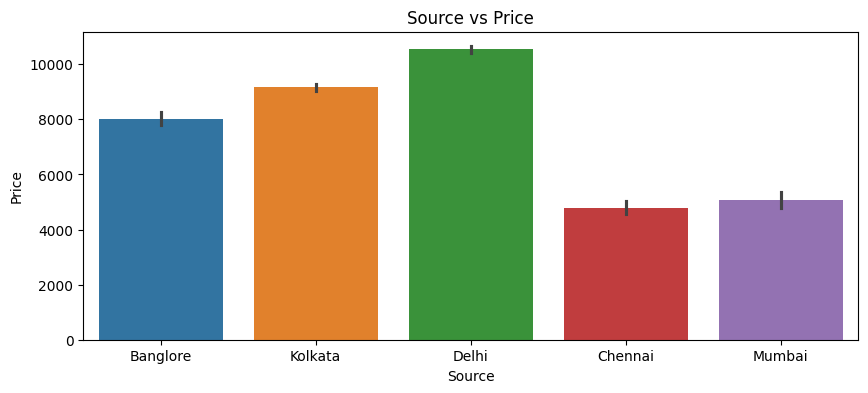

In [67]:
# Source vs Price (C vs N)

plt.figure(figsize=(10,4))

sns.barplot(x='Source', 
            y='Price', 
            hue='Source',
            data=flight_cost
           )

plt.title('Source vs Price')

plt.show()

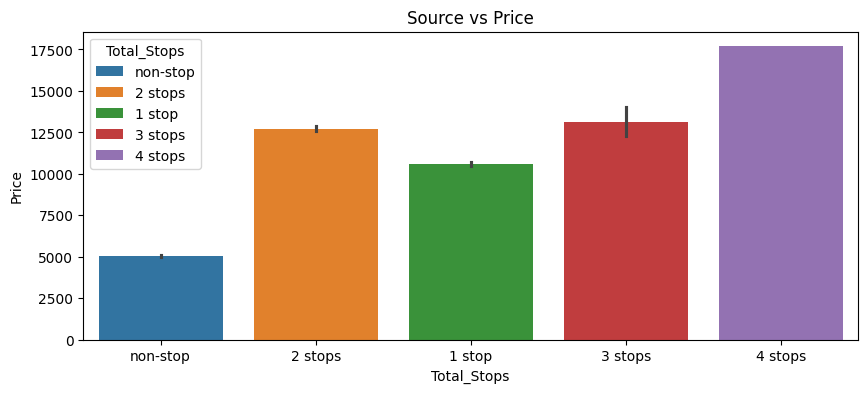

In [66]:
# Total_Stops vs Price (C vs N)

plt.figure(figsize=(10,4))

sns.barplot(x='Total_Stops',
            y='Price',
            hue='Total_Stops',
            data=flight_cost,
           )

plt.title('Source vs Price')

plt.show()

#### Multi-Variant Analysis

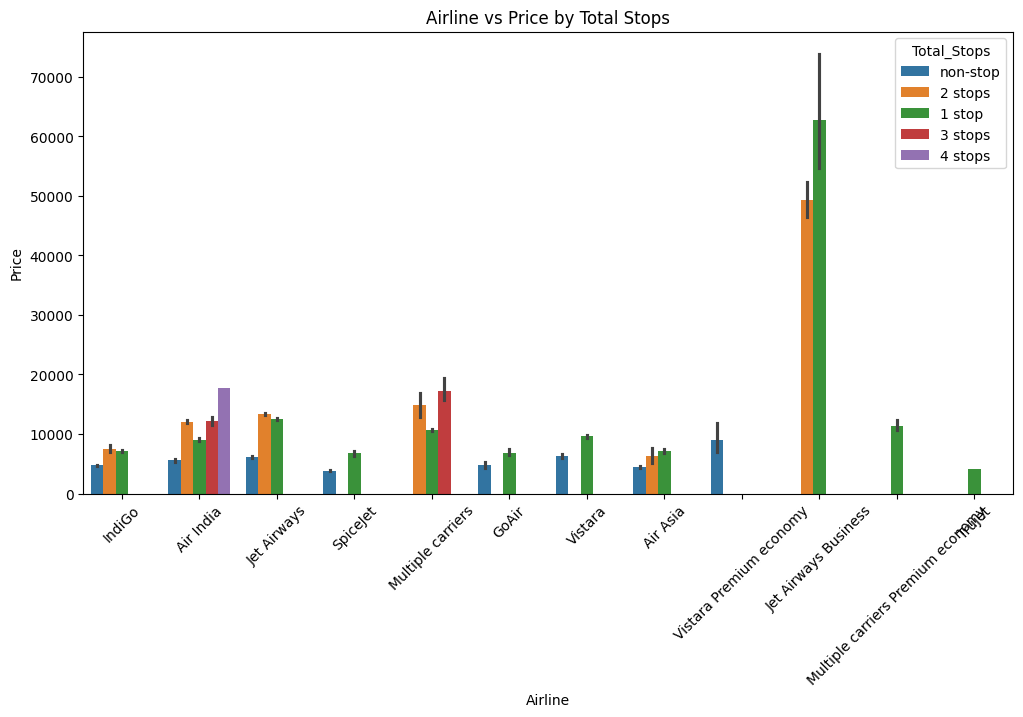

In [63]:
plt.figure(figsize=(12,6))

sns.barplot(x='Airline',
            y='Price',
            hue='Total_Stops',
            data=flight_cost)

plt.xticks(rotation=45)
plt.title("Airline vs Price by Total Stops")
plt.show() 